In [2]:
def plot_lc(time, flux, c=None, ylim=(0.9865, 1.0025), ax=None):
    if ax is None:
        fig, ax = subplots()
    else:
        fig, ax = None, ax
    ax.plot(time, flux, c=c)
    ax.autoscale(axis='x', tight=True)
    setp(ax, xlabel='Time [d]', ylabel='Flux', xlim=time[[0,-1]], ylim=ylim)
    
    if fig is not None:
        fig.tight_layout()
    return ax

In [3]:
from pytransit import RoadRunnerModel

In [4]:
time = linspace(-0.05, 0.05, 1500)

In [5]:
tm = RoadRunnerModel('nonlinear')
tm.set_data(time)

In [6]:
flux1 = tm.evaluate(k=0.1, ldc=[0.36, 0.04, 0.1, 0.05], t0=0.0, p=1.0, a=4.2, i=0.5*pi, e=0.0, w=0.0)

### Evaluation for a set of parameters

Like the rest of the *PyTransit* transit models, the *RoadRunner* model can be evaluated simultaneously for a set of parameters. This is also done using *tm.evaluate*, but now each argument is a vector with ``npv`` values. Model evaluation is parallelised and can be significantly faster than looping over an parameter array in Python.

Now, the ``tm.evaluate`` returns a 2D array with shape ``[npv, npt]`` with the transit model evaluated for each parameter vector and mid-transit time given in the ``time`` array

In [9]:
flux2 = tm.evaluate(ks, ldc, t0s, ps, smas, incs, es, os)

### Supersampling

A single photometry observation is always an exposure over time. If the exposure time is short compared to the changes in the transit signal shape during the exposure, the observation can be modelled by evaluating the model at the mid-exposure time. However, if the exposure time is long, we need to simluate the integration by calculating the model average over the exposure time (although numerical integration is also a valid approach, it is slightly more demanding computationally and doesn't improve the accuracy significantly). This is achieved by supersampling the model, that is, evaluating the model at several locations inside the exposure and averaging the samples.

Evaluating the model many times for each observation naturally increases the computational burden of the model, but is necessary to model long-cadence observations from the *Kepler* and *TESS* telescopes.

In [12]:
flux3 = tm.evaluate(k=0.1, ldc=[0.36, 0.04, 0.1, 0.05], t0=0.0, p=1.0, a=4.2, i=0.5*pi, e=0.0, w=0.0)

## Example 2: heterogeneous light curve
### Multiple passbands

*PyTransit* aims to simplify modelling of heterogeneous light curves as much as possible. Here heterogeneous means that we can model light curves observed in different passbands, with different instruments, and with different supersampling requirements in one go. This is because most of the real exoplanet transit modelling science cases nowadays involve heterogeneous datasets, such as modelling long-cadence *Kepler* light curves together with short-cadence ground-based observations, or transmission spectroscopy where the light curves are created from a spectroscopic time series. 

To model heterogeneous light curves, *PyTransit* designates each observation (exposure, datapoint) to a specific light curve, and each light curve to a specific passband. This is done throught the light curve index array (``lcids``) and passband index array (``pbids``). Light curve index array is an integer array giving an index for each observed datapoints (suchs as, the indices for dataset of light curves would be either 0 or 1), while the passband index array is an integer array containing a passband index for each light curve in the dataset. So, a dataset of two light curves observed in a same passband would be

    times = [0, 1, 2, 3]
    lcids = [0, 0, 1, 1]
    pbids = [0, 0]
    
while a dataset containing two light curves observed in different passbands would be

    times = [0, 1, 2, 3]
    lcids = [0, 0, 1, 1]
    pbids = [0, 1]
    
Let's create two datasets. The first one divides our single light curve into two halves parts and gives each a different light curve index (0 for the first half and 1 for the second)

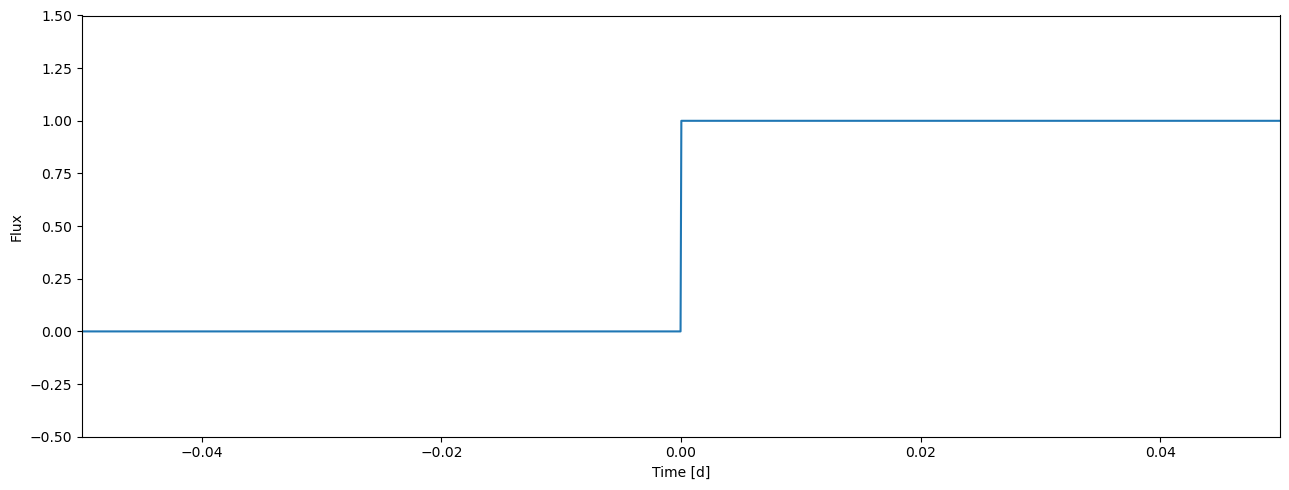

In [15]:
plot_lc(time, lcids1, ylim=(-0.5, 1.5));

In [16]:
time2 = tile(time, 3)
lcids2 = repeat([0, 1, 1], time.size)

#### Achromatic radius ratio

Let's see how this works in practice. We divide our current light curve into two halves observed in different passbands. These passbands have different limb darkening, but we first assume that the radius ratio is achromatic.

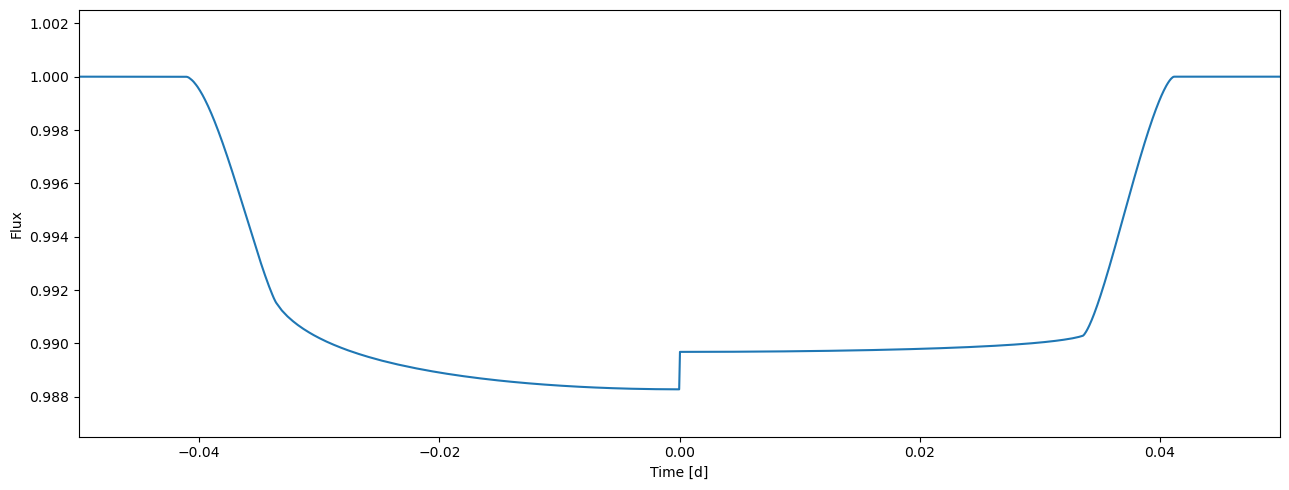

In [19]:
flux = tm.evaluate(k=0.1, ldc=[[3.1, 0.1],[2.1, 0.03]], t0=0.0, p=1.0, a=4.3, i=0.5*pi)
plot_lc(time, flux);

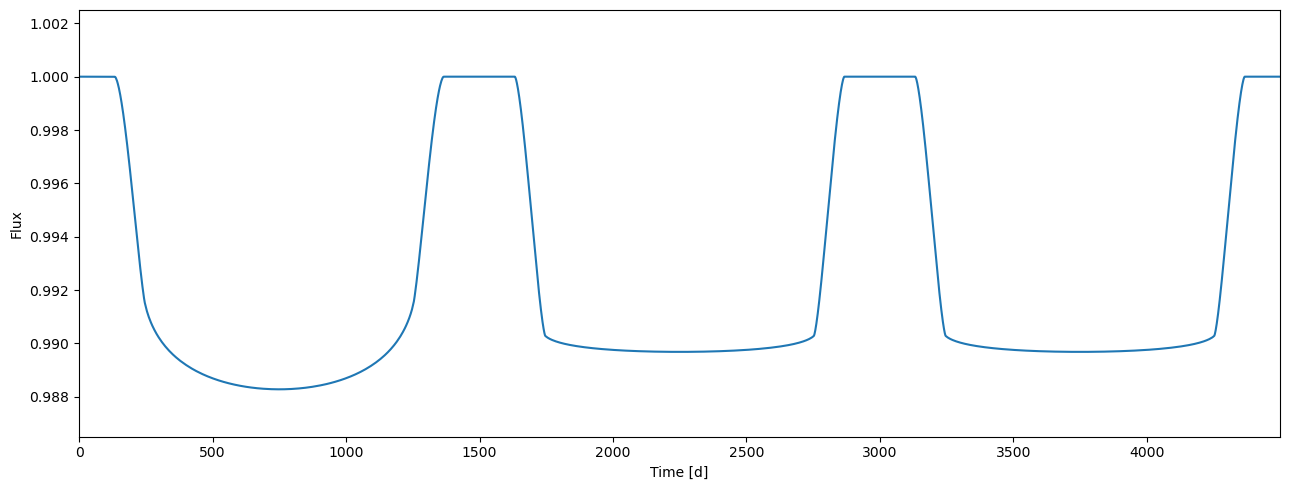

In [21]:
flux = tm.evaluate(k=0.1, ldc=[[3.1, 0.1],[2.1, 0.03]], t0=0.0, p=1.0, a=4.3, i=0.5*pi)
plot_lc(arange(flux.size), flux);

In [22]:
tm.set_data(time, lcids=lcids1, pbids=[0, 1])

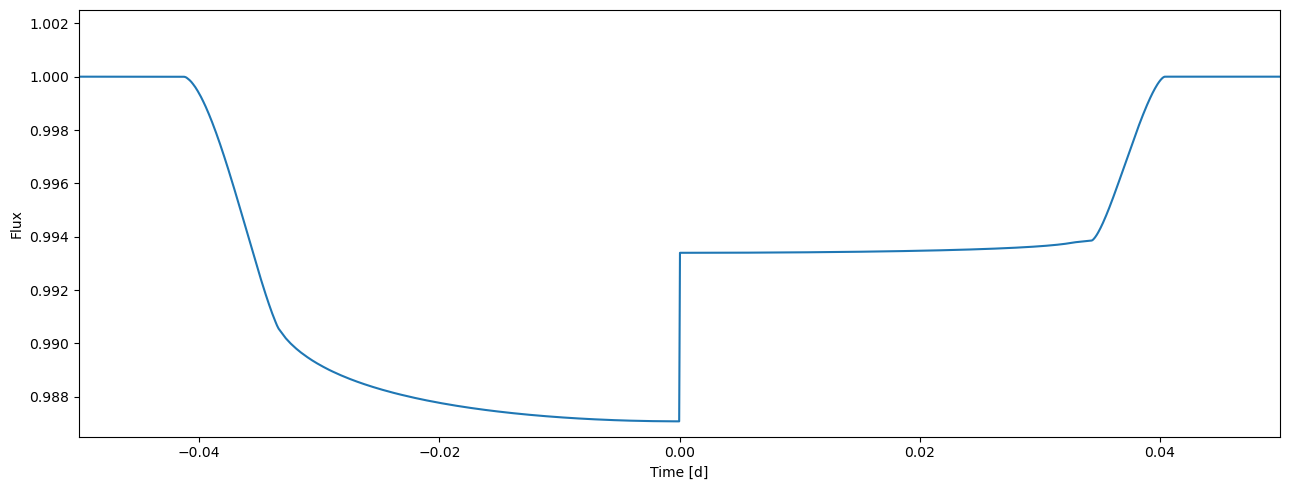

In [24]:
plot_lc(time, flux);

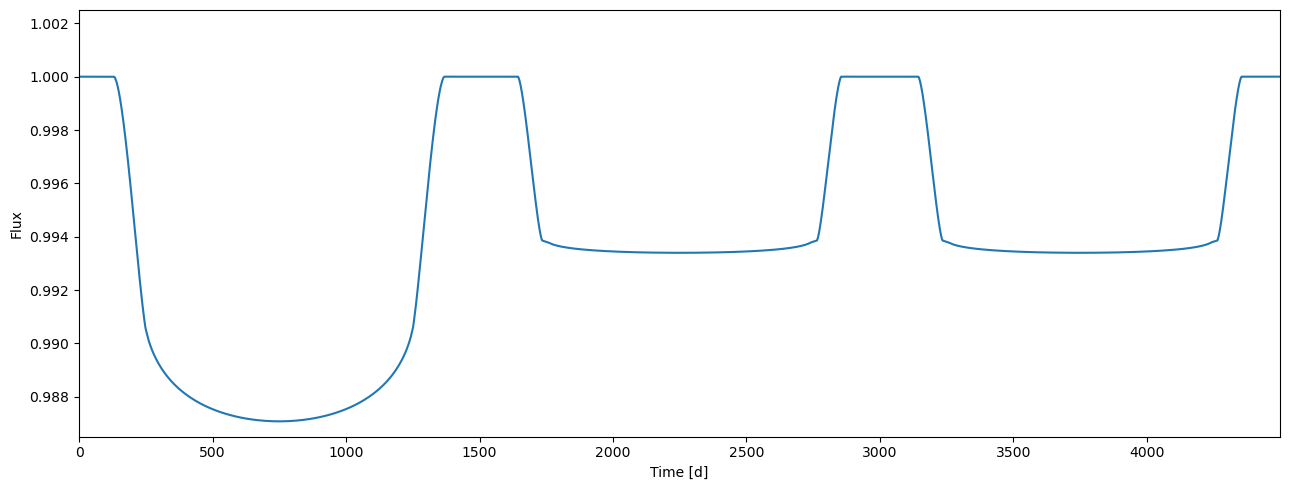

In [26]:
flux = tm.evaluate(k=[0.105, 0.08], ldc=[[3.1, 0.1],[2.1, 0.03]], t0=0.0, p=1.0, a=4.3, i=0.5*pi)
plot_lc(arange(flux.size), flux);

In [27]:
tm.set_data(time, lcids=lcids1, exptimes=[0.0, 0.02], nsamples=[1, 10])

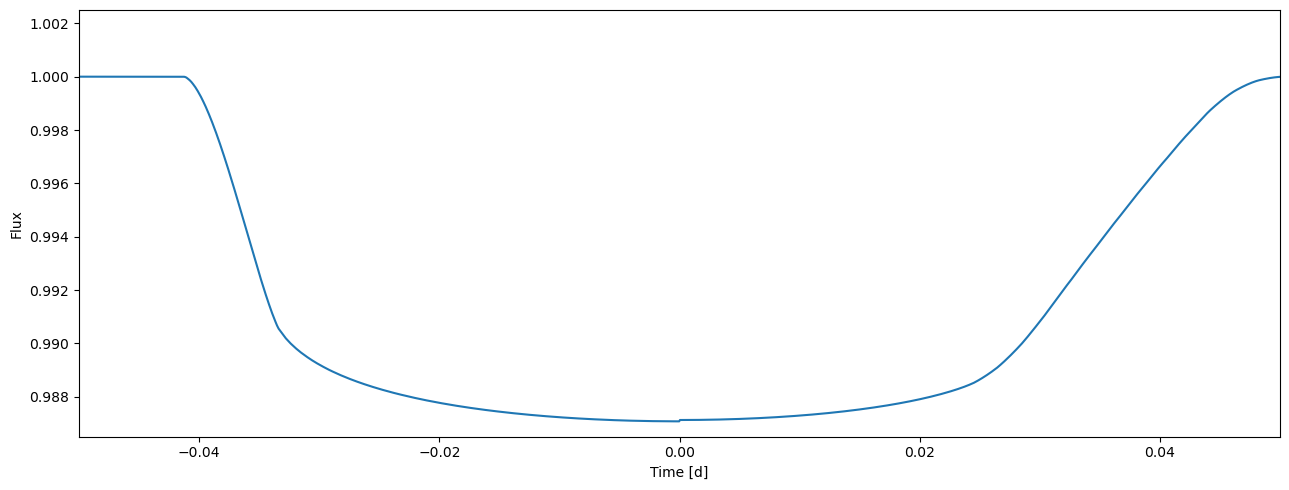

In [29]:
plot_lc(time, flux);

In [31]:
flux = tm.evaluate(k=0.105, ldc=[3.1, 0.1], t0=0.0, p=1.0, a=4.3, i=0.5*pi)

### Everything together

Finally, let's throw everything together and create a set of light curves observed in different passbands, requiring different supersampling rates, assuming chromatic radius ratios, for a set of parameter vectors.

In [34]:
npv = 5
ks    = uniform(0.09, 0.1, (npv, 3))
t0s   = normal(0, 0.002, npv)
ps    = normal(1.0, 0.01, npv)
smas  = normal(5.0, 0.1, npv)
incs  = uniform(0.48*pi, 0.5*pi, npv)
es    = uniform(0, 0.25, size=npv)
os    = uniform(0, 2*pi, size=npv)
ldc   = uniform(0, 0.5, size=(npv,3,2))

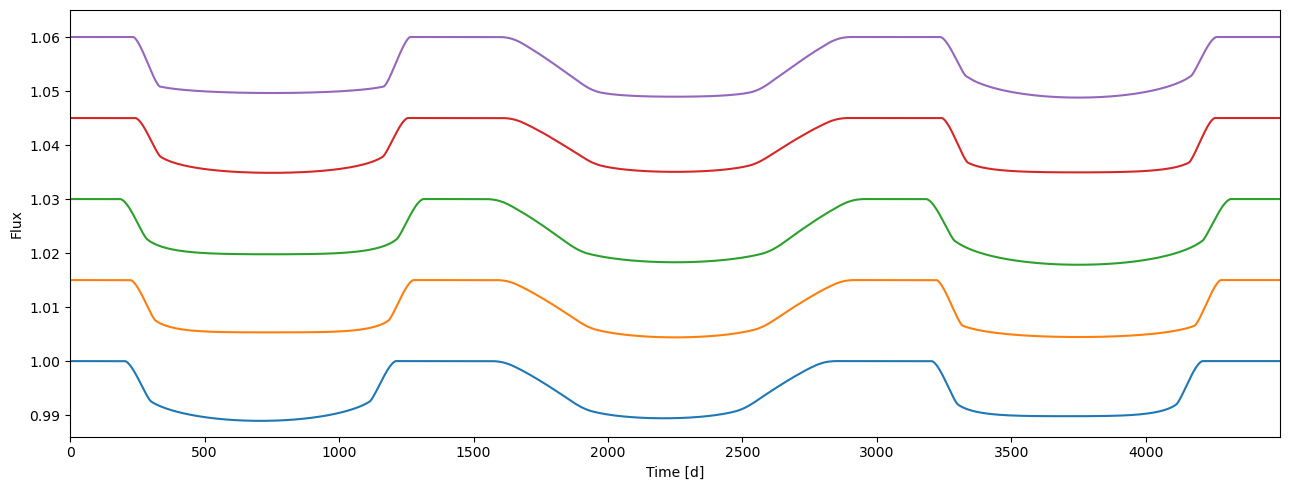

In [36]:
plot_lc(arange(flux.shape[1]), flux.T + linspace(0, 0.06, npv), ylim=(0.986, 1.065));